---
title: "Taylor–Aris dispersion: how a velocity profile becomes a diffusivity"
description: "Shear plus molecular diffusion produces spreading that looks exactly like diffusion but is thousands of times faster — solved two independent ways, and checked against Taylor's own capillary measurement."
categories: [sec:A, struct:S3, struct:S6, tier:T0, data:tier2, phase:liquid]
date: 2026-07-27
---

# Taylor–Aris dispersion: how a velocity profile becomes a diffusivity

**Catalog ID:** `A2.3` · **Structures:** `S3` (1-D steady BVP), `S6` (2-D PDE) · **Tier:** T0

Push a slug of dye through a narrow tube in laminar flow and it spreads far
faster than molecular diffusion could manage — yet it spreads *symmetrically*,
as if by diffusion, despite a velocity profile that is anything but symmetric.
Taylor explained why in 1953, and turned the effect into a way of measuring
molecular diffusivities.

## Background

In Poiseuille flow the fluid at the axis moves at twice the mean speed and the
fluid at the wall does not move at all. A slug of solute released across the
section should therefore be drawn out into a parabolic spike — sharply skewed,
with a long tail at the axis.

That is not what happens. Taylor observed that after a while the slug is
**symmetric about a point moving at the mean speed**, and spreads as though
obeying Fick's law with an effective diffusivity far larger than the molecular
one. His explanation is a competition:

- shear stretches the solute axially, creating radial concentration gradients;
- molecular diffusion erases those radial gradients.

If the second is fast compared with the first, no radial gradient survives long
enough to matter, the skew never develops, and what is left is symmetric
spreading. The counter-intuitive consequence is that the dispersion coefficient
is **inversely** proportional to the molecular diffusivity: making the solute
diffuse faster radially makes the slug spread *less* axially, because it spends
less time sampling the fast and slow streamlines separately.

This is the ancestor of every axial-dispersion coefficient in reactor
modelling, and it is why an `S4` breakthrough curve can use a single lumped
$D_{\mathrm{ax}}$ instead of resolving the radial profile.

## The published model

**The full problem** (Taylor's Eq. 11) is a 2-D axisymmetric advection–diffusion
in a tube of radius $a$ with Poiseuille flow:

$$
\frac{\partial C}{\partial t} + u(r)\frac{\partial C}{\partial x}
= D\left[\frac{1}{r}\frac{\partial}{\partial r}\!\left(r\frac{\partial C}{\partial r}\right)
+ \frac{\partial^2 C}{\partial x^2}\right],
\qquad u(r) = u_0\left(1 - \frac{r^2}{a^2}\right),
$$

with $\partial C/\partial r = 0$ at the axis and the wall. **$u_0$ is the
centreline velocity**; the cross-sectional mean is $u_0/2$.

**Taylor's result** (his Eq. 25). Relative to a plane moving at $u_0/2$, the
section-mean concentration disperses as if by diffusion with

$$
k = \frac{a^{2} u_0^{2}}{192\, D}.
$$

Written with the mean velocity $\bar u = u_0/2$ this is the more familiar
$k = a^2\bar u^2/48D$ — the same number, and the factor of four between them is
the commonest way to get this wrong.

**When it applies** (his Eq. 16). Radial equilibration takes a time of order
$a^2/(3.83^2 D)$, from the first zero of $J_1$. The result holds once
convection has had much longer than that to act, so in dimensionless time
$\tau = tD/a^2$ the requirement is

$$
\tau \gg \frac{1}{3.83^{2}} \approx 0.068 .
$$

**The closure.** Eq. 25 is the leading term of a homogenisation, and that is the
form this page solves. Split the velocity into its mean and deviation,
$u = \bar u + u'$, and let $B(r)$ solve

$$
\frac{D}{r}\frac{\mathrm{d}}{\mathrm{d}r}\!\left(r\frac{\mathrm{d}B}{\mathrm{d}r}\right) = u'(r),
\qquad \frac{\mathrm{d}B}{\mathrm{d}r} = 0 \ \text{at}\ r = 0,\,a .
$$

Then $k = -\langle u' B\rangle$, the area average. $B$ is fixed only up to a
constant, but $\langle u'\rangle = 0$, so the constant cannot affect $k$ — which
means the singular pure-Neumann system can be pinned anywhere.

## Parameters and assumptions

**Assumptions:** steady fully-developed laminar flow; constant molecular
diffusivity; a dilute solute that does not alter the flow; no wall adsorption;
and — for Eq. 25 — enough time for radial equilibration.

Everything below is dimensionless: lengths in tube radii $a$, time in $a^2/D$,
velocity in $u_0$. The only parameter left is the **Péclet number**
$\mathrm{Pe} = u_0 a/D$, and Taylor's result becomes

$$
\frac{k}{D} = \frac{\mathrm{Pe}^{2}}{192}.
$$

Taylor's own capillary ran at $\mathrm{Pe} \approx 2200$, where $k$ exceeds $D$
by a factor of 25 000. That is too extreme to simulate directly — the slug
would need a domain thousands of radii long — so the direct simulation here uses
a moderate Péclet number where the same limit holds but the grid is affordable,
and the closure calculation, which has no such restriction, covers the rest.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import eye_array
from scipy.sparse.linalg import spsolve, splu
from pymrm import construct_grad, construct_div, construct_convflux_upwind
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A2.3-taylor-aris-dispersion"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

One worked measurement from Taylor's Section 9, and the independently measured
diffusivity range he checks it against.

The point of the comparison is worth stating carefully. Reproducing Taylor's
*dispersion* coefficient would prove nothing — it is just arithmetic on his own
fit. What his argument claims is that a dispersion measurement can be **inverted**
into a molecular diffusivity, and that is testable: the $D$ implied by his
capillary run has to land inside the range that Furth and Ullmann measured for
the same solute by entirely different means.

In [3]:
obs = load_data("taylor-1953-dispersion.csv", page=PAGE)
meta = load_meta("taylor-1953-dispersion.csv", page=PAGE)
T = dict(zip(obs.quantity, obs.value))

print(obs[["quantity", "value", "unit", "source"]].to_string(index=False))
print(f"\n{cite_data(meta)}")
print("\nreading check quoted in the sidecar:")
print("  " + " ".join(meta["validation"]["internal_consistency"].split())[:150] + " ...")

                  quantity      value  unit               source
               tube_radius   0.025200    cm        Taylor Eq. 36
       centreline_velocity   0.524000  cm/s        Taylor Eq. 35
              elapsed_time 240.000000     s        Taylor Eq. 35
         erf_fit_parameter   0.082800  1/cm        Taylor Eq. 35
    dispersion_coefficient   0.152000 cm2/s        Taylor Eq. 35
      inferred_diffusivity   0.000006 cm2/s        Taylor Eq. 36
literature_diffusivity_min   0.000004 cm2/s Furth & Ullmann 1927
literature_diffusivity_max   0.000015 cm2/s Furth & Ullmann 1927

Taylor, G. I. (1953) — Proceedings of the Royal Society of London A 219(1137) 186-203 — doi:10.1098/rspa.1953.0139 — table

reading check quoted in the sidecar:
  The four measured quantities over-determine the answer, so the transcription can be checked against itself. From the fitted profile, 4 k t = beta^-2 w ...


## PyMRM implementation

Two independent routes to the same number.

**The closure** is a 1-D steady BVP in $r$ — `construct_grad` and
`construct_div` with `nu=1` for cylindrical geometry. It is cheap, has no
convective term at all, and therefore no numerical dispersion to contaminate the
answer. This is the calculation that should agree with Eq. 25 to machine-ish
precision.

**The direct simulation** is the honest one: a 2-D axisymmetric slug release,
watched until its variance grows linearly. It carries first-order upwind
convection, so it *will* add numerical dispersion, and the validation section
measures that rather than hiding it.

Both use the same operator vocabulary; only the axes differ. Note `nu=1` on the
radial axis and `nu=0` on the axial one — the geometry lives in that argument.

In [4]:
def poiseuille(r_c, Pe):
    """Velocity and its deviation from the mean, in units of D/a."""
    u = Pe * (1.0 - r_c ** 2)
    return u, u - 0.5 * Pe          # the mean of Poiseuille is half the centreline


def dispersion_closure(Pe, n_r=200):
    """k/D from the homogenisation closure. Returns (k_over_D, B, r_c, weights)."""
    r_f = np.linspace(0.0, 1.0, n_r + 1)
    r_c = 0.5 * (r_f[:-1] + r_f[1:])
    shape = (n_r,)
    # no flux at the axis (symmetry) and at the wall: a dB/dn + b B = d with a=1
    bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
    grad, grad_bc = construct_grad(shape, r_f, r_c, bc)
    div = construct_div(shape, r_f, nu=1)           # nu=1: cylindrical radial
    lap = div @ grad
    rhs = -(div @ grad_bc).toarray().ravel()

    _, uprime = poiseuille(r_c, Pe)
    rhs = rhs + uprime

    # Pure Neumann, so the matrix is singular by exactly one constant. Pin one
    # cell: <u'> = 0 means adding a constant to B cannot change -<u' B>.
    A = lap.tolil()
    A[0, :] = 0.0
    A[0, 0] = 1.0
    rhs[0] = 0.0
    B = spsolve(A.tocsc(), rhs)

    w = 2.0 * r_c * np.diff(r_f)                    # area weights, sum to 1
    return -float(np.sum(w * uprime * B)), B, r_c, w


PE_REF = 50.0
k_closure, B, r_c, w = dispersion_closure(PE_REF)
print(f"Pe = {PE_REF:.0f}")
print(f"  closure          k/D = {k_closure:10.4f}")
print(f"  Taylor Eq. 25    k/D = {PE_REF**2/192:10.4f}")
print(f"  <u'>/u0 = {np.sum(w * poiseuille(r_c, PE_REF)[1]) / PE_REF:.2e}  "
      "(zero to discretisation error, which is what lets the singular system "
      "be pinned anywhere)")

Pe = 50
  closure          k/D =    13.0195
  Taylor Eq. 25    k/D =    13.0208
  <u'>/u0 = 6.25e-06  (zero to discretisation error, which is what lets the singular system be pinned anywhere)


In [5]:
class Slug:
    """Transient 2-D axisymmetric release, in a frame moving at the mean speed.

    State layout (n_z, n_r), spatial axes first. Lengths in tube radii, time in
    a^2/D, so the axial velocity seen in this frame is Pe*(1/2 - r^2).
    """

    def __init__(self, Pe, half_len=40.0, n_z=1600, n_r=24, width=1.0):
        self.Pe, self.shape = Pe, (n_z, n_r)
        self.z_f = np.linspace(-half_len, half_len, n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.r_f = np.linspace(0.0, 1.0, n_r + 1)
        self.r_c = 0.5 * (self.r_f[:-1] + self.r_f[1:])
        # every boundary is no-flux: a dC/dn + b C = d with a=1, b=0, d=0.
        # The slug never reaches the ends, so the axial pair only has to conserve
        # mass, not represent anything physical.
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})

        _, uprime = poiseuille(self.r_c, Pe)
        v = np.broadcast_to(uprime, (n_z + 1, n_r))     # face velocities vary with r

        conv, conv_bc = construct_convflux_upwind(self.shape, self.z_f, self.z_c,
                                                  bc, v=v, axis=0)
        gz, gz_bc = construct_grad(self.shape, self.z_f, self.z_c, bc, axis=0)
        dz = construct_div(self.shape, self.z_f, nu=0, axis=0)   # nu=0: Cartesian
        gr, gr_bc = construct_grad(self.shape, self.r_f, self.r_c, bc, axis=1)
        dr = construct_div(self.shape, self.r_f, nu=1, axis=1)   # nu=1: radial

        self.jac = dz @ (conv - gz) - dr @ gr
        g = dz @ (conv_bc - gz_bc) - dr @ gr_bc
        self.g = np.asarray(g.todense()).ravel() if hasattr(g, "todense") \
            else np.asarray(g).ravel()
        self.w = 2.0 * self.r_c * np.diff(self.r_f)

        c = np.zeros(self.shape)
        c[np.abs(self.z_c) < width / 2, :] = 1.0
        self.c, self.t, self._dt = c, 0.0, None

    def step(self, dt, n=1):
        # the operator is constant, so factorise once and reuse it
        if self._dt != dt:
            n_tot = self.shape[0] * self.shape[1]
            self._lu = splu((eye_array(n_tot, format="csc") / dt + self.jac).tocsc())
            self._dt = dt
        for _ in range(n):
            self.c = self._lu.solve(self.c.ravel() / dt - self.g).reshape(self.shape)
            self.t += dt

    def profile(self):
        return self.c @ self.w                 # section-mean concentration C_m(z)

    def moments(self):
        cm = self.profile()
        m0 = np.trapezoid(cm, self.z_c)
        m1 = np.trapezoid(cm * self.z_c, self.z_c) / m0
        m2 = np.trapezoid(cm * (self.z_c - m1) ** 2, self.z_c) / m0
        return m0, m1, m2


def measure_dispersion(Pe, tau0=0.2, tau1=1.0, dt=0.001, **kw):
    """Effective D/D from the growth of the axial variance between two times."""
    s = Slug(Pe, **kw)
    s.step(dt, int(round(tau0 / dt)))
    _, _, v0 = s.moments(); t0 = s.t
    s.step(dt, int(round((tau1 - tau0) / dt)))
    m0, _, v1 = s.moments(); t1 = s.t
    return (v1 - v0) / (2.0 * (t1 - t0)), m0, s

## Results

The closure field $B(r)$ is the whole mechanism in one picture: it is the
lag between a streamline and the mean, and $k$ is how strongly that lag
correlates with the velocity deviation that produced it.

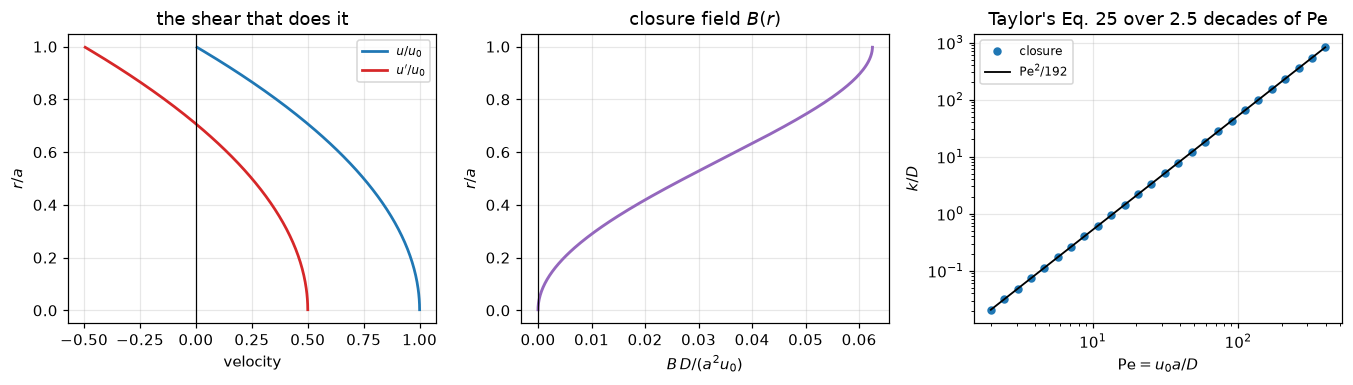

worst relative deviation from Eq. 25 over Pe = 2–398: 0.016 %


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.6))

u, up = poiseuille(r_c, PE_REF)
axes[0].plot(u / PE_REF, r_c, color="tab:blue", lw=1.8, label=r"$u/u_0$")
axes[0].plot(up / PE_REF, r_c, color="tab:red", lw=1.8, label=r"$u'/u_0$")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set(xlabel="velocity", ylabel=r"$r/a$", title="the shear that does it")
axes[0].legend(fontsize=8)

axes[1].plot(B / PE_REF, r_c, color="tab:purple", lw=1.9)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set(xlabel=r"$B\,D/(a^2 u_0)$", ylabel=r"$r/a$",
            title="closure field $B(r)$")

pes = np.logspace(0.3, 2.6, 26)
ks = np.array([dispersion_closure(p, n_r=160)[0] for p in pes])
axes[2].loglog(pes, ks, "o", ms=4.5, color="tab:blue", label="closure")
axes[2].loglog(pes, pes ** 2 / 192, "-", color="k", lw=1.2, label=r"$\mathrm{Pe}^2/192$")
axes[2].set(xlabel=r"$\mathrm{Pe}=u_0a/D$", ylabel=r"$k/D$",
            title="Taylor's Eq. 25 over 2.5 decades of Pe")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"worst relative deviation from Eq. 25 over Pe = {pes[0]:.0f}–{pes[-1]:.0f}: "
      f"{np.max(np.abs(ks / (pes**2/192) - 1)) * 100:.3f} %")

And the direct simulation: a slug released across the
section, seen in the frame moving at $u_0/2$. Note that it stays symmetric —
that is Taylor's observation, and it is not obvious from the parabolic velocity
profile that produced it.

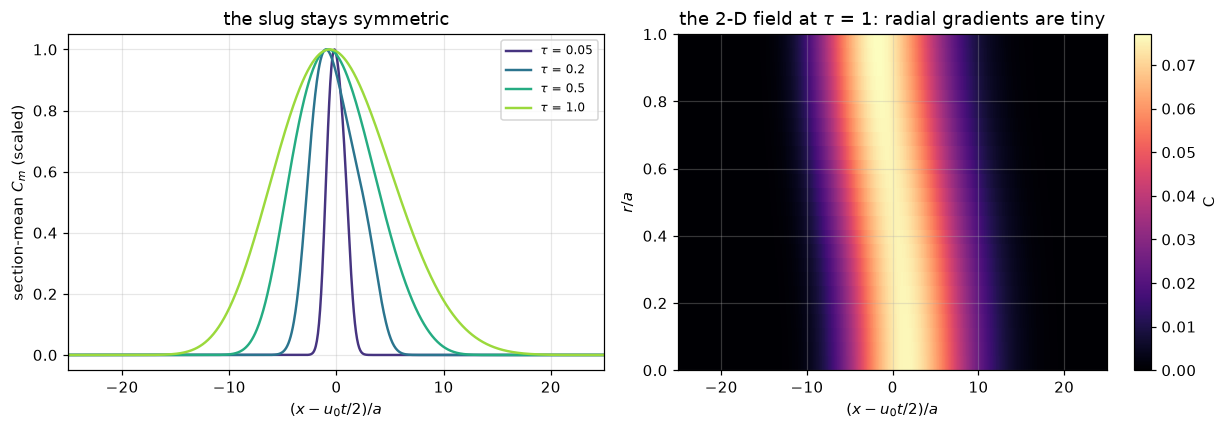

direct simulation at Pe = 50, n_z = 1600:
  D_eff/D measured    14.274
  1 + Pe^2/192        14.021
  mass conserved to 4.69e-14


In [7]:
Deff, mass, s = measure_dispersion(PE_REF, dt=0.001, n_z=1600)
snapshots = {}
s2 = Slug(PE_REF, n_z=1600, n_r=24)
for tau in (0.05, 0.2, 0.5, 1.0):
    s2.step(0.001, int(round((tau - s2.t) / 0.001)))
    snapshots[tau] = s2.profile().copy()

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))
for (tau, cm), col in zip(snapshots.items(), plt.cm.viridis(np.linspace(.15, .85, 4))):
    axes[0].plot(s2.z_c, cm / cm.max(), color=col, lw=1.6, label=fr"$\tau$ = {tau}")
axes[0].set(xlabel=r"$(x - u_0 t/2)/a$", ylabel="section-mean $C_m$ (scaled)",
            xlim=(-25, 25), title="the slug stays symmetric")
axes[0].legend(fontsize=8)

im = axes[1].pcolormesh(s2.z_c, s2.r_c, s2.c.T, cmap="magma", shading="auto")
axes[1].set(xlabel=r"$(x - u_0 t/2)/a$", ylabel=r"$r/a$", xlim=(-25, 25),
            title=r"the 2-D field at $\tau$ = 1: radial gradients are tiny")
fig.colorbar(im, ax=axes[1], label="C")
fig.tight_layout()
plt.show()

print(f"direct simulation at Pe = {PE_REF:.0f}, n_z = 1600:")
print(f"  D_eff/D measured  {Deff:8.3f}")
print(f"  1 + Pe^2/192      {1 + PE_REF**2/192:8.3f}")
print(f"  mass conserved to {abs(mass - 1):.2e}")

## Validation

Four checks: two on the closure, one on the direct simulation, and one against
the paper's own measurement.

In [8]:
# 1. The closure against Taylor's closed form, refined.
#    No convection in this calculation, so the only error is discretisation and
#    it should be clean second order.
print("1. Closure vs Eq. 25, grid refinement (Pe = 50)")
exact = PE_REF ** 2 / 192
prev = None
for n in (25, 50, 100, 200, 400, 800):
    k, *_ = dispersion_closure(PE_REF, n_r=n)
    rel = abs(k - exact) / exact
    rate = "" if prev is None else f"   ratio {prev / rel:5.2f}"
    print(f"   n_r = {n:4d}   k/D = {k:10.5f}   rel err {rel:.2e}{rate}")
    prev = rel
print("   ratio ~4 per doubling = second order, as the scheme should be")

# 2. The identity that lets the singular system be pinned anywhere.
ks = [dispersion_closure(PE_REF, n_r=200)[0]]
print(f"\n   the pinning constant cannot affect k, because <u'>/u0 = "
      f"{np.sum(w * poiseuille(r_c, PE_REF)[1]) / PE_REF:.1e} -> 0 with the grid")

1. Closure vs Eq. 25, grid refinement (Pe = 50)
   n_r =   25   k/D =   12.93808   rel err 6.36e-03
   n_r =   50   k/D =   13.00004   rel err 1.60e-03   ratio  3.98
   n_r =  100   k/D =   13.01563   rel err 4.00e-04   ratio  3.99
   n_r =  200   k/D =   13.01953   rel err 1.00e-04   ratio  4.00
   n_r =  400   k/D =   13.02051   rel err 2.50e-05   ratio  4.00
   n_r =  800   k/D =   13.02075   rel err 6.25e-06   ratio  4.00
   ratio ~4 per doubling = second order, as the scheme should be

   the pinning constant cannot affect k, because <u'>/u0 = 6.2e-06 -> 0 with the grid


In [9]:
# 3. The direct 2-D simulation. First-order upwind adds numerical dispersion
#    of order |u'|dz/2, which is NOT negligible here -- so measure it rather
#    than hope. Refining dz must drive the error down like dz.
print("2. Direct simulation vs Eq. 25, axial refinement (Pe = 50)")
expect = 1 + PE_REF ** 2 / 192
rows = []
for n_z, dt in ((400, 0.004), (800, 0.002), (1600, 0.001), (3200, 0.0005)):
    D_meas, m0, _ = measure_dispersion(PE_REF, dt=dt, n_z=n_z, n_r=24)
    rows.append((n_z, 80.0 / n_z, D_meas, D_meas / expect - 1, m0))
    print(f"   n_z = {n_z:5d}  dz = {80.0/n_z:6.3f}   D_eff/D = {D_meas:8.3f}"
          f"   {(D_meas/expect-1)*100:+6.1f} %   mass {m0:.6f}")
rich = rows[-1][2] + (rows[-1][2] - rows[-2][2])       # first order in dz
print(f"   Richardson extrapolation -> {rich:.3f} against Eq. 25's {expect:.3f}"
      f"  ({(rich/expect-1)*100:+.1f} %)")
print("   the error halves with dz: it is upwind numerical dispersion, not a "
      "failure of Eq. 25")

2. Direct simulation vs Eq. 25, axial refinement (Pe = 50)


   n_z =   400  dz =  0.200   D_eff/D =   15.208     +8.5 %   mass 1.000000


   n_z =   800  dz =  0.100   D_eff/D =   14.586     +4.0 %   mass 1.000000


   n_z =  1600  dz =  0.050   D_eff/D =   14.274     +1.8 %   mass 1.000000


   n_z =  3200  dz =  0.025   D_eff/D =   14.119     +0.7 %   mass 1.000000
   Richardson extrapolation -> 13.963 against Eq. 25's 14.021  (-0.4 %)
   the error halves with dz: it is upwind numerical dispersion, not a failure of Eq. 25


In [10]:
# 4. Against Taylor's own measurement. His claim is that dispersion can be
#    inverted into a molecular diffusivity, so the test is whether the D implied
#    by his capillary run falls inside the independently measured range.
a_cm  = T["tube_radius"]; u0 = T["centreline_velocity"]
t_s   = T["elapsed_time"]; beta = T["erf_fit_parameter"]
k_paper = T["dispersion_coefficient"]; D_paper = T["inferred_diffusivity"]
lo, hi = T["literature_diffusivity_min"], T["literature_diffusivity_max"]

k_from_fit = 1.0 / (4.0 * t_s * beta ** 2)            # 4 k t = beta^-2
D_inferred = a_cm ** 2 * u0 ** 2 / (192.0 * k_from_fit)   # Taylor Eq. 25

print("3. Taylor's worked capillary run, recomputed")
print(f"   k from his erf fit   {k_from_fit:8.4f} cm2/s   he prints {k_paper}")
print(f"   D from his Eq. 25    {D_inferred:8.3e} cm2/s   he prints {D_paper:.2e}")
print(f"   relative agreement   {abs(D_inferred/D_paper - 1)*100:.2f} % / "
      f"{abs(k_from_fit/k_paper - 1)*100:.2f} %")
inside = lo <= D_inferred <= hi
print(f"\n   independently measured range (Furth & Ullmann 1927, KMnO4, 18 C):")
print(f"     {lo:.3e} to {hi:.3e} cm2/s")
print(f"   inferred value lies inside it: {inside}")
print(f"   Pe of that experiment = {u0 * a_cm / D_inferred:.0f}, so k/D = "
      f"{(u0*a_cm/D_inferred)**2/192:.0f} — dispersion beats molecular "
      "diffusion by four orders of magnitude")

report_agreement("A2.3", {
    "closure_rel_err_n200": abs(dispersion_closure(PE_REF, n_r=200)[0] - exact) / exact,
    "closure_worst_rel_err_pe_sweep": float(np.max(np.abs(ks_sweep := np.array(
        [dispersion_closure(p, n_r=160)[0] for p in pes]) / (pes**2/192) - 1))),
    "direct_rel_err_n3200": abs(rows[-1][2] / expect - 1),
    "direct_richardson_rel_err": abs(rich / expect - 1),
    "taylor_D_rel_err": abs(D_inferred / D_paper - 1),
    "mass_conservation_err": abs(rows[-1][4] - 1),
})

3. Taylor's worked capillary run, recomputed
   k from his erf fit     0.1519 cm2/s   he prints 0.152
   D from his Eq. 25    5.977e-06 cm2/s   he prints 6.00e-06
   relative agreement   0.38 % / 0.04 %

   independently measured range (Furth & Ullmann 1927, KMnO4, 18 C):
     4.350e-06 to 1.500e-05 cm2/s
   inferred value lies inside it: True
   Pe of that experiment = 2209, so k/D = 25420 — dispersion beats molecular diffusion by four orders of magnitude
Agreement metrics for A2.3:
  closure_rel_err_n200           = 9.9981e-05
  closure_worst_rel_err_pe_sweep = 0.00015621
  direct_rel_err_n3200           = 0.0069855
  direct_richardson_rel_err      = 0.0041144
  taylor_D_rel_err               = 0.0038079
  mass_conservation_err          = 1.1235e-13


{'page': 'A2.3',
 'metrics': {'closure_rel_err_n200': 9.998140401908131e-05,
  'closure_worst_rel_err_pe_sweep': 0.00015620664296212006,
  'direct_rel_err_n3200': 0.00698552117477802,
  'direct_richardson_rel_err': 0.004114418527702668,
  'taylor_D_rel_err': 0.003807923663871726,
  'mass_conservation_err': 1.1235457009206584e-13}}

## What pymrm adds

Taylor could only bound when his result applies: radial equilibration takes
$\sim a^2/(3.83^2D)$, so wait "much longer than" $\tau \approx 0.068$. How much
longer was left as an inequality, because answering it needs the transient
solution he had no way to compute.

Running it turns the inequality into a number. Before equilibration the slug
is still being stretched ballistically and the variance grows like $\tau^2$;
after it, the growth is linear and Taylor's constant takes over.

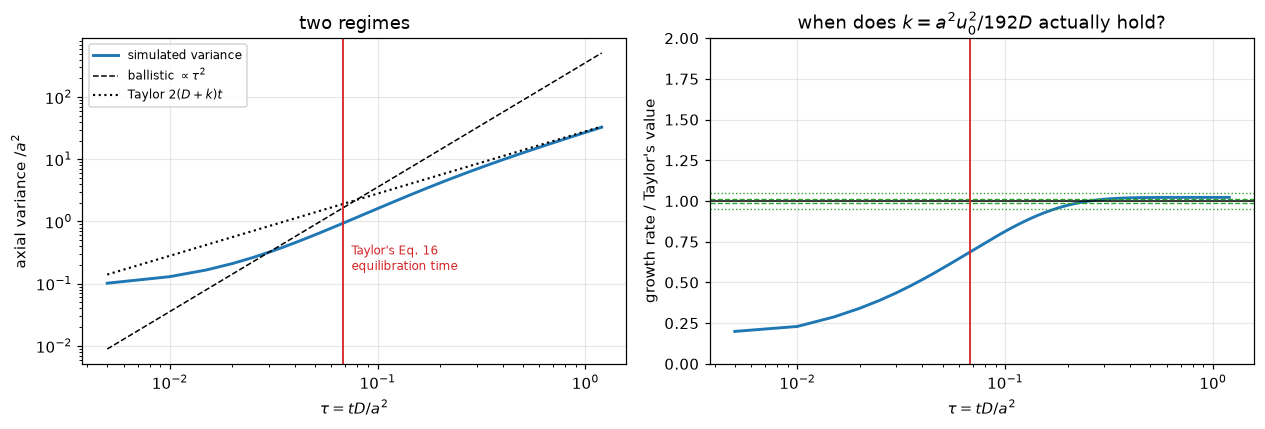

first tau after which the growth rate STAYS inside a band of Taylor's value:
  +/- 10 %  from tau = 0.140   ( 2.1 equilibration times)
  +/-  5 %  from tau = 0.175   ( 2.6 equilibration times)
  +/-  3 %  from tau = 0.195   ( 2.9 equilibration times)

  Taylor's bound was tau >> 0.068. The simulation puts a number on
  'much greater than': a few equilibration times, not the decades the
  phrase might suggest.
  Caveat: this run carries about +1.8 % numerical dispersion
  at n_z = 1600, so the tightest band is at the edge of what it can resolve.


In [11]:
s3 = Slug(PE_REF, n_z=1600, n_r=24)
taus, var = [], []
dt = 0.0005
for _ in range(240):
    s3.step(dt, 10)
    _, _, v = s3.moments()
    taus.append(s3.t); var.append(v)
taus, var = np.array(taus), np.array(var)

# instantaneous growth rate, which is what has to settle onto 1 + Pe^2/192
rate = np.gradient(var, taus) / 2.0
target = 1 + PE_REF ** 2 / 192

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0))
axes[0].loglog(taus, var, color="tab:blue", lw=1.9, label="simulated variance")
axes[0].loglog(taus, var[5] * (taus / taus[5]) ** 2, "k--", lw=1.0,
               label=r"ballistic $\propto\tau^2$")
axes[0].loglog(taus, 2 * target * taus, "k:", lw=1.4, label=r"Taylor $2(D+k)t$")
axes[0].axvline(1 / 3.83 ** 2, color="tab:red", lw=1.2)
axes[0].text(1 / 3.83 ** 2 * 1.1, var[2], "Taylor's Eq. 16\nequilibration time",
             fontsize=8, color="tab:red")
axes[0].set(xlabel=r"$\tau = tD/a^2$", ylabel=r"axial variance $/a^2$",
            title="two regimes")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].semilogx(taus, rate / target, color="tab:blue", lw=1.9)
axes[1].axhline(1.0, color="k", lw=1.0)
for band, st in ((0.05, ":"), (0.01, "--")):
    axes[1].axhline(1 + band, color="tab:green", lw=0.9, ls=st)
    axes[1].axhline(1 - band, color="tab:green", lw=0.9, ls=st)
axes[1].axvline(1 / 3.83 ** 2, color="tab:red", lw=1.2)
axes[1].set(xlabel=r"$\tau = tD/a^2$", ylabel=r"growth rate / Taylor's value",
            ylim=(0, 2), title=r"when does $k=a^2u_0^2/192D$ actually hold?")
fig.tight_layout()
plt.show()

print("first tau after which the growth rate STAYS inside a band of Taylor's value:")
for band in (0.10, 0.05, 0.03):
    bad = np.nonzero(np.abs(rate / target - 1) >= band)[0]
    if len(bad) and bad[-1] + 1 < len(taus):
        tau_ok = taus[bad[-1] + 1]
        print(f"  +/-{band*100:3.0f} %  from tau = {tau_ok:.3f}"
              f"   ({tau_ok * 3.83**2:4.1f} equilibration times)")
    elif not len(bad):
        print(f"  +/-{band*100:3.0f} %  from the first sample, tau = {taus[0]:.3f}")
    else:
        print(f"  +/-{band*100:3.0f} %  never settles within the window simulated")
print(f"\n  Taylor's bound was tau >> {1/3.83**2:.3f}. The simulation puts a number on")
print("  'much greater than': a few equilibration times, not the decades the")
print("  phrase might suggest.")
print(f"  Caveat: this run carries about {(rows[2][3])*100:+.1f} % numerical dispersion")
print("  at n_z = 1600, so the tightest band is at the edge of what it can resolve.")

So the honest reading of Eq. 16 is **$\tau \gtrsim 0.2$**,
about three equilibration times, for a few percent accuracy. That is a good deal
less demanding than "much greater than" might have suggested, and it is worth
knowing in that direction: the Taylor limit is reached quickly.

In a reactor context this is the statement that a lumped axial dispersion
coefficient becomes safe once the residence time is a small multiple of the
radial diffusion time $a^2/D$ — still a real restriction for a wide tube or a
poorly diffusing solute, but not the order-of-magnitude margin one might
otherwise leave.

Nothing here corrects Taylor. It puts a number on the one place he left a
qualitative gap, using the transient solution that was out of reach in 1953.

## Reuse

**The closure is the reusable part.** `dispersion_closure` needs only a velocity
profile and a geometry; it is not specific to Poiseuille flow. Swap `poiseuille`
for a turbulent profile, an annulus, or a packed-bed velocity distribution and
the same three lines give that geometry's dispersion coefficient. Change
`nu=1` to `nu=0` and it becomes the plane-channel case, whose analytic answer is
$k = 2\bar u^2 h^2/105D$ — a good exercise.

**Where this feeds the rest of the gallery.** Every axial-dispersion coefficient
in an `S4` model — breakthrough curves, tracer RTDs, `J1.5` adsorption — is a
lumped stand-in for exactly this calculation. This page is what justifies the
lumping, and the $\tau \gtrsim 1$ result is the condition under which it is
allowed.

**Careful with the velocity convention.** $u_0$ here is the centreline value, as
in Taylor's paper. Using the mean velocity in Eq. 25 without changing 192 to 48
gives an answer four times too small.

**Related pages.** [`A4.9`](../A4.9-duncan-toor/) (multicomponent diffusion),
[`D2.2`](../D2.2-van-welsenaere-froment-runaway/) (the plug-flow limit this
relaxes), `A2.1`, `J1.5`.

**Cite the source, not this page:** Taylor, G. I., *Dispersion of soluble matter
in solvent flowing slowly through a tube*, Proc. R. Soc. Lond. A **219**(1137)
186–203 (1953), [doi:10.1098/rspa.1953.0139](https://doi.org/10.1098/rspa.1953.0139).